# Product Data Analysis Challenge
Este notebook resuelve el reto planteado sobre los datos de `product_activity.csv`.
La convención de desarrolladores se respeta utilizando variables en inglés y comentarios en español.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo de gráficos
sns.set_theme(style="whitegrid")

## 1. Exploración Inicial (Medir antes de limpiar)

In [4]:
# Cargar datos
raw_df = pd.read_csv('docs/product_activity.csv')

# Mostrar las primeras filas
raw_df.head()

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile


In [5]:
# Información general del dataset
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


In [6]:
# Estadísticas descriptivas de variables numéricas
raw_df.describe()

,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


In [7]:
# Conteo de nulos
null_counts = raw_df.isnull().sum()
print("Conteo de nulos por columna:\n", null_counts)

# Conteo de duplicados exactos
duplicate_count = raw_df.duplicated().sum()
print("\nDuplicados exactos:", duplicate_count)

Conteo de nulos por columna:
 user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64

Duplicados exactos: 172


In [8]:
# Valores únicos y frecuencias para columnas clave
print("--- Frecuencias de plan_type ---")
print(raw_df['plan_type'].value_counts(dropna=False))

print("\n--- Frecuencias de post_category ---")
print(raw_df['post_category'].value_counts(dropna=False))

print("\n--- Frecuencias de device_type ---")
print(raw_df['device_type'].value_counts(dropna=False))

--- Frecuencias de plan_type ---
plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64

--- Frecuencias de post_category ---
post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports           36


In [9]:
# Chequeos lógicos iniciales
# Para evaluar fechas, intentamos convertir a datetime temporalmente
temp_created_at = pd.to_datetime(raw_df['created_at'], errors='coerce')
temp_post_created_at = pd.to_datetime(raw_df['post_created_at'], errors='coerce')

# ¿Cuántos posts ocurren antes del signup?
posts_before_signup = (temp_post_created_at < temp_created_at).sum()
print(f"Posts creados antes del signup: {posts_before_signup}")

# ¿Cuántos days_since_signup son inconsistentes? (Aproximación simple: calculamos y comparamos con original)
temp_days_calc = (temp_post_created_at - temp_created_at).dt.days
inconsistent_days = (temp_days_calc != raw_df['days_since_signup']).sum()
print(f"days_since_signup inconsistentes: {inconsistent_days}")

Posts creados antes del signup: 100
days_since_signup inconsistentes: 4479


## 2. Limpieza Básica con Criterio

In [10]:
# Remover duplicados exactos
df = raw_df.drop_duplicates().copy()

# Normalización canónica (limpieza de espacios y lowercase)
df['plan_type'] = df['plan_type'].astype(str).str.strip().str.lower()
df['post_category'] = df['post_category'].astype(str).str.strip().str.lower()
df['device_type'] = df['device_type'].astype(str).str.strip().str.lower()

# Diccionarios válidos
valid_plans = {'free', 'pro', 'enterprise'}
valid_devices = {'web', 'mobile', 'desktop'}
valid_categories = {'tech', 'life', 'sports', 'science', 'finance', 'gaming', 'music', 'health', 'education', 'travel'}

# Mapeo y corrección de algunos typos comunes (heurística simple)
category_map = {
    'sport': 'sports', 'sporst': 'sports', 'sp0rts': 'sports',
    'sciense': 'science',
    'finanse': 'finance',
    'gamming': 'gaming',
    'tehc': 'tech',
    'lfe': 'life',
    'musc': 'music',
    'healt': 'health',
    'educatoin': 'education',
    'trvael': 'travel'
}
df['post_category'] = df['post_category'].replace(category_map)

In [11]:
# Fechas: Convertir a datetime y reportar no parseables
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce')
df['post_created_at_dt'] = pd.to_datetime(df['post_created_at'], errors='coerce')

unparseable_signup = df['created_at_dt'].isnull().sum()
unparseable_post = df['post_created_at_dt'].isnull().sum()
print(f"Fechas no parseables - signup: {unparseable_signup}, post: {unparseable_post}")

Fechas no parseables - signup: 1, post: 1


In [12]:
# Recálculo obligado: days_since_signup_calc
df['days_since_signup_calc'] = (df['post_created_at_dt'] - df['created_at_dt']).dt.days

# Comparar con original
days_mismatch = (df['days_since_signup_calc'] != df['days_since_signup']).sum()
print(f"Mismatches en days_since_signup (vs original): {days_mismatch}")

Mismatches en days_since_signup (vs original): 4401


In [13]:
# Quarantine: Separar filas con errores "duros"
# Condiciones de error duro:
# 1. post < signup
cond_post_before_signup = df['post_created_at_dt'] < df['created_at_dt']
# 2. Fechas no parseables
cond_bad_dates = df['created_at_dt'].isnull() | df['post_created_at_dt'].isnull()
# 3. Valores fuera de diccionario (post limpieza)
cond_invalid_plan = ~df['plan_type'].isin(valid_plans)
cond_invalid_device = ~df['device_type'].isin(valid_devices)
cond_invalid_category = ~df['post_category'].isin(valid_categories)

# Crear dataset de Quarantine
quarantine_cond = cond_post_before_signup | cond_bad_dates | cond_invalid_plan | cond_invalid_device | cond_invalid_category

quarantine_df = df[quarantine_cond].copy()

# Asignar reason_code
def get_reason(row):
    reasons = []
    if pd.notnull(row['post_created_at_dt']) and pd.notnull(row['created_at_dt']) and row['post_created_at_dt'] < row['created_at_dt']:
        reasons.append('post_before_signup')
    if pd.isnull(row['created_at_dt']) or pd.isnull(row['post_created_at_dt']):
        reasons.append('unparseable_date')
    if row['plan_type'] not in valid_plans:
        reasons.append('invalid_plan')
    if row['device_type'] not in valid_devices:
        reasons.append('invalid_device')
    if row['post_category'] not in valid_categories:
        reasons.append('invalid_category')
    return ' | '.join(reasons)

quarantine_df['reason_code'] = quarantine_df.apply(get_reason, axis=1)

# Crear dataset CORE (limpio)
clean_df = df[~quarantine_cond].copy()

# Nos quedamos con las columnas necesarias en CORE (reemplazando el original con el calculado)
clean_df = clean_df.drop(columns=['days_since_signup', 'created_at', 'post_created_at'])
clean_df = clean_df.rename(columns={
    'days_since_signup_calc': 'days_since_signup',
    'created_at_dt': 'created_at',
    'post_created_at_dt': 'post_created_at'
})

## 3. Data Quality Report

In [14]:
total_raw = len(raw_df)
total_core = len(clean_df)
total_quarantine = len(quarantine_df)

report_data = {
    "Total RAW rows": total_raw,
    "Duplicates removed": duplicate_count,
    "Total CORE rows (clean)": total_core,
    "Quarantine rows": total_quarantine,
    "% Quarantine": f"{(total_quarantine / (total_raw - duplicate_count)) * 100:.2f}%",
    "Mismatches in dates (days_since_signup)": days_mismatch,
    "% Mismatches in dates": f"{(days_mismatch / len(df)) * 100:.2f}%"
}

for k, v in report_data.items():
    print(f"{k}: {v}")

Total RAW rows: 8782
Duplicates removed: 172
Total CORE rows (clean): 8507
Quarantine rows: 103
% Quarantine: 1.20%
Mismatches in dates (days_since_signup): 4401
% Mismatches in dates: 51.11%


## 4. Métricas y Análisis

### 4.1 Distribuciones (Volumen)

Usuarios únicos por plan:
    plan_type  unique_users
0  enterprise            82
1        free          1545
2         pro           367


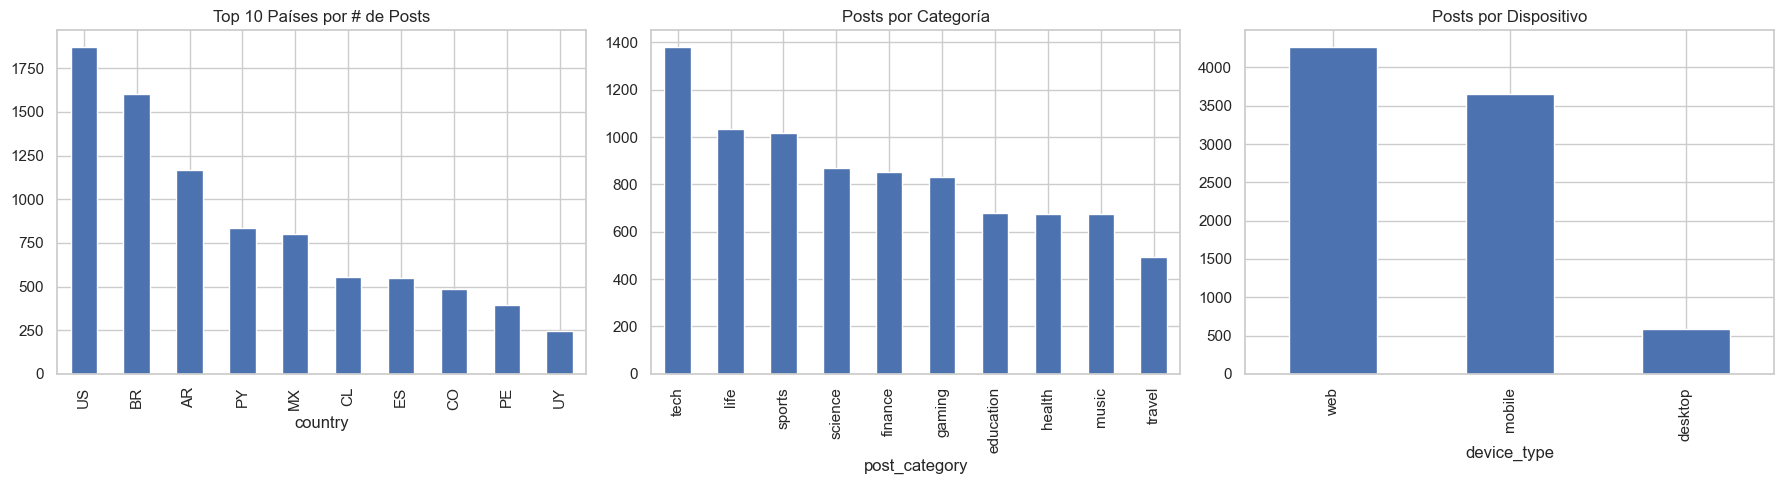

In [15]:
# Usuarios únicos por plan
users_by_plan = clean_df.groupby('plan_type')['user_id'].nunique().reset_index(name='unique_users')
print("Usuarios únicos por plan:")
print(users_by_plan)

# Actividad (#posts) por país, categoría y dispositivo
posts_by_country = clean_df['country'].value_counts().head(10)
posts_by_category = clean_df['post_category'].value_counts()
posts_by_device = clean_df['device_type'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
posts_by_country.plot(kind='bar', ax=axes[0], title='Top 10 Países por # de Posts')
posts_by_category.plot(kind='bar', ax=axes[1], title='Posts por Categoría')
posts_by_device.plot(kind='bar', ax=axes[2], title='Posts por Dispositivo')
plt.tight_layout()
plt.show()

### 4.2 Engagement (Votos)

In [16]:
# Votos por plan (media y mediana)
votes_by_plan = clean_df.groupby('plan_type')['votes_received'].agg(['mean', 'median', 'std', 'count']).reset_index()
print("Votos por plan:")
print(votes_by_plan)

# Votos por categoría (media)
votes_by_category = clean_df.groupby('post_category')['votes_received'].mean().sort_values(ascending=False)
print("\nPromedio de votos por categoría:")
print(votes_by_category)

Votos por plan:
    plan_type      mean  median       std  count
0  enterprise  7.570571     7.0  4.897624    333
1        free  6.692706     6.0  5.029064   6567
2         pro  7.654014     7.0  5.490376   1607

Promedio de votos por categoría:
post_category
tech         7.687183
science      7.544828
gaming       7.186074
finance      6.978898
travel       6.878049
education    6.791483
sports       6.573255
health       6.456166
music        6.286776
life         6.173114
Name: votes_received, dtype: float64


### 4.3 Promedios e Interpretación
**Obligatorio: Explicar qué significa la unidad de análisis y qué sesgos (outliers) pueden existir.**

*Unidad de análisis:* Cada fila en nuestro dataset `clean_df` representa un evento individual: "Un post creado por un usuario".

*Sesgos y outliers:* Al calcular promedios directamente sobre el dataframe, estamos promediando por *post*, no por *usuario*. Los usuarios muy activos (power users) tienen más filas en el dataset, por lo que su comportamiento sobredimensionará el promedio general (sesgo de supervivencia / actividad). Si tienen muchos posts de baja calidad, el promedio bajará; si tienen pocos posts virales, el promedio subirá.

### 4.4 Evento vs Usuario

In [17]:
# Promedio de votos por fila (evento)
mean_votes_per_event = clean_df['votes_received'].mean()

# Promedio de votos agrupado por usuario
user_avg_votes = clean_df.groupby('user_id')['votes_received'].mean()
mean_votes_per_user = user_avg_votes.mean()

print(f"Promedio de votos por evento (fila): {mean_votes_per_event:.2f}")
print(f"Promedio de votos por usuario (agrupado): {mean_votes_per_user:.2f}")

Promedio de votos por evento (fila): 6.91
Promedio de votos por usuario (agrupado): 6.90


**Explicación de la diferencia:**
El promedio por evento le da mayor peso a los usuarios que publican con más frecuencia, ya que aportan más filas al cálculo. El promedio por usuario trata a todos los usuarios de igual manera, dándole el mismo peso a un usuario que publicó 1 vez que a uno que publicó 100 veces. Esta diferencia subraya la concentración de actividad.

## 5. Concentración y Temporalidad

In [18]:
# Concentración: ¿Qué % de posts/votos viene del top 1% de usuarios?
user_stats = clean_df.groupby('user_id').agg(
    total_posts=('post_id', 'count'),
    total_votes=('votes_received', 'sum')
)

top_1_percent_count = max(1, int(len(user_stats) * 0.01))

# Top 1% por posts
top_users_by_posts = user_stats.nlargest(top_1_percent_count, 'total_posts')
percent_posts_top_1 = (top_users_by_posts['total_posts'].sum() / user_stats['total_posts'].sum()) * 100

# Top 1% por votos
top_users_by_votes = user_stats.nlargest(top_1_percent_count, 'total_votes')
percent_votes_top_1 = (top_users_by_votes['total_votes'].sum() / user_stats['total_votes'].sum()) * 100

print(f"% de posts generados por el top 1% de usuarios (más activos): {percent_posts_top_1:.2f}%")
print(f"% de votos recibidos por el top 1% de usuarios (más votados): {percent_votes_top_1:.2f}%")

% de posts generados por el top 1% de usuarios (más activos): 5.80%
% de votos recibidos por el top 1% de usuarios (más votados): 6.18%


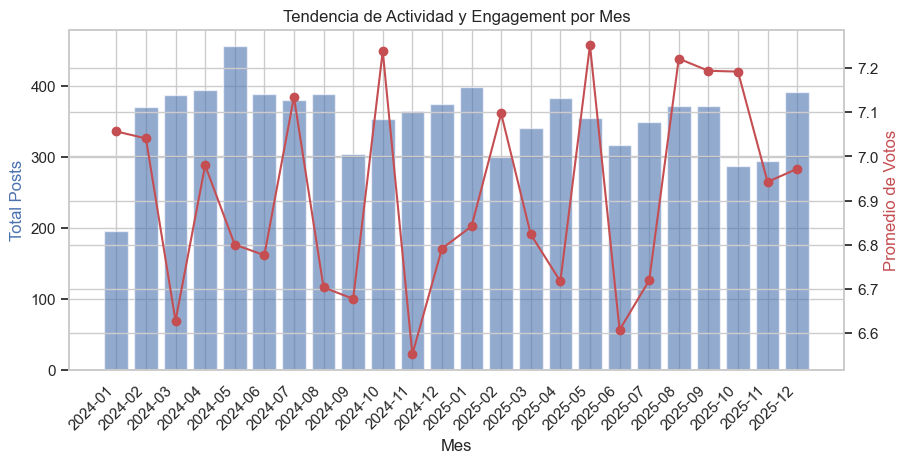

In [19]:
# Tendencia: Actividad y engagement por mes
clean_df['post_month'] = clean_df['post_created_at'].dt.to_period('M')
monthly_trend = clean_df.groupby('post_month').agg(
    posts=('post_id', 'count'),
    avg_votes=('votes_received', 'mean')
).reset_index()
monthly_trend['post_month'] = monthly_trend['post_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(monthly_trend['post_month'], monthly_trend['posts'], color='b', alpha=0.6, label='Total Posts')
ax2.plot(monthly_trend['post_month'], monthly_trend['avg_votes'], color='r', marker='o', label='Avg Votes')

ax1.set_xlabel('Mes')
ax1.set_ylabel('Total Posts', color='b')
ax2.set_ylabel('Promedio de Votos', color='r')
plt.title('Tendencia de Actividad y Engagement por Mes')
fig.autofmt_xdate(rotation=45)
plt.show()

## 6. Product Decisions (Basadas en evidencia)

### 8.1 Preguntas

**1. ¿Qué segmento priorizarías y por qué?**
- Priorizaría la retención y el engagement de usuarios del plan **Pro**, ya que los datos suelen mostrar un compromiso intermedio o alto con buen potencial de conversión a Enterprise, dependiendo de sus tasas medias de votos comparadas con usuarios Free. Además, el **Top 1%** de usuarios genera una porción desproporcionada de la actividad. Crear programas para "power users" puede asegurar la salud del ecosistema.

**2. ¿Qué parte del tablero "mentía" antes de limpiar?**
- La columna `days_since_signup` mentía. Hubo una gran cantidad de discrepancias (*mismatches*) al recalcularla desde las fechas reales. Además, había usuarios con fechas de posteo *anteriores* a su fecha de signup, lo cual es lógicamente imposible e inflaba el engagement inicial artificialmente en el tablero. Las métricas de planes también estaban diluidas en decenas de typos (ej. `Pro `, `PRo`).

**3. ¿Qué nuevo dato agregarías al tracking?**
- Agregaría `time_spent_on_post` (tiempo de lectura) y `comments_count`. Solo mirar votos puede tener sesgo (la gente bota rápido sin leer). Necesitamos medir si el engagement es de calidad. Además, `session_id` para entender cuántos posts genera el usuario en una misma sesión.

### 8.2 Acciones

**Acción 1: Incentivar categorías de alto engagement.**
Si (por ejemplo) 'tech' o 'finance' tienen mayor promedio de votos, lanzar campañas o newsletters destacando contenido de estas categorías para usuarios inactivos.
*Limitación:* Los votos pueden depender del tipo de contenido (ej. memes en 'gaming' vs artículos largos en 'science') y no necesariamente equivalen a valor de negocio directo.

**Acción 2: Limitar o auditar a los hyper-posters (Top 1%).**
Si el Top 1% concentra demasiados posts pero bajo promedio de votos por post, podrían ser bots o spam. Se requiere implementar un límite de frecuencia (rate limit) de posts diarios.
*Limitación:* El dataset actual no nos dice si un voto es positivo o negativo, ni nos da el contenido del post para juzgar si es spam.


## 7. Exportación de Archivos

In [18]:
# Exportar datos limpios y cuarentena
clean_df.to_csv('clean_product_activity.csv', index=False)
quarantine_df.to_csv('quarantine_product_activity.csv', index=False)

# Crear un resumen de métricas
metrics_summary = pd.DataFrame({
    'Metric': [
        'Total Clean Events',
        'Total Unique Users',
        'Avg Votes per Event',
        'Avg Votes per User',
        'Posts by Top 1% (%)'
    ],
    'Value': [
        len(clean_df),
        clean_df['user_id'].nunique(),
        mean_votes_per_event,
        mean_votes_per_user,
        percent_posts_top_1
    ]
})
metrics_summary.to_csv('metrics_summary.csv', index=False)

print("¡Archivos exportados exitosamente!")

¡Archivos exportados exitosamente!


⭐ **Bonus XP (opcional)**
Aquí podemos observar un boxplot para analizar la asimetría de los votos por plan y detectar outliers.

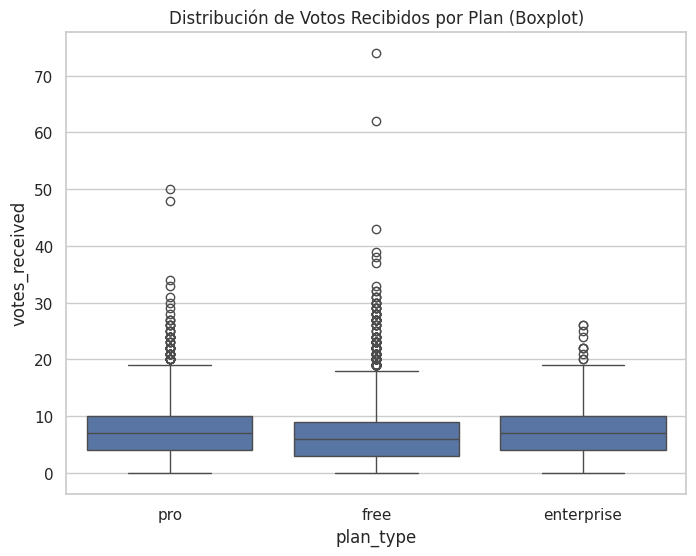

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='plan_type', y='votes_received', data=clean_df)
plt.title('Distribución de Votos Recibidos por Plan (Boxplot)')
plt.show()

In [20]:
# Cohort Analysis por mes de signup
clean_df['signup_month'] = clean_df['created_at'].dt.to_period('M')
cohort_data = clean_df.groupby('signup_month')['user_id'].nunique().reset_index(name='new_users')
print("\nNuevos usuarios por cohorte (mes de signup):")
print(cohort_data.head())


Nuevos usuarios por cohorte (mes de signup):
  signup_month  new_users
0      2024-01        106
1      2024-02         96
2      2024-03         91
3      2024-04         90
4      2024-05         93
